# Week 10 수업 예제: Backpropagation을 위한 수학 도구

1. 미분과 편미분을 NumPy/SymPy로 계산
2. 그래디언트 시각화 (등고선 + 화살표)
3. Chain rule 적용 예시
4. Sigmoid 미분 확인
5. Gradient descent 실습 (1D, 2D)

준비: 같은 폴더에 `gradient_descent.py`가 있어야 합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


---
## 예제 1: 미분의 수치적 계산

**수업 슬라이드 5-6과 대응**

정의식 `f'(a) ≈ [f(a+h) - f(a)] / h`를 이용해 수치 미분을 구합니다.

In [2]:
def numerical_derivative(f, a, h=1e-5):
    """중앙 차분법으로 수치 미분."""
    return (f(a + h) - f(a - h)) / (2 * h)

# f(x) = x^2 의 미분을 여러 점에서
f = lambda x: x**2
f_prime_analytical = lambda x: 2*x  # 해석적 정답

print("x     | 수치 미분 | 해석 미분 | 차이")
print("-" * 45)
for x in [-2, -1, 0, 1, 2, 3]:
    numerical = numerical_derivative(f, x)
    analytical = f_prime_analytical(x)
    print(f"{x:+d}    | {numerical:+.4f}   | {analytical:+d}         | {abs(numerical-analytical):.2e}")

x     | 수치 미분 | 해석 미분 | 차이
---------------------------------------------
-2    | -4.0000   | -4         | 2.62e-11
-1    | -2.0000   | -2         | 2.00e-12
+0    | +0.0000   | +0         | 0.00e+00
+1    | +2.0000   | +2         | 2.00e-12
+2    | +4.0000   | +4         | 2.62e-11
+3    | +6.0000   | +6         | 3.93e-11


**관찰**: 수치 미분과 해석적 미분이 거의 일치합니다. 이것이 Week 11에서 gradient check에 쓰이는 원리입니다.

---
## 예제 2: 여러 점에서의 접선 시각화

**수업 슬라이드 5와 대응**

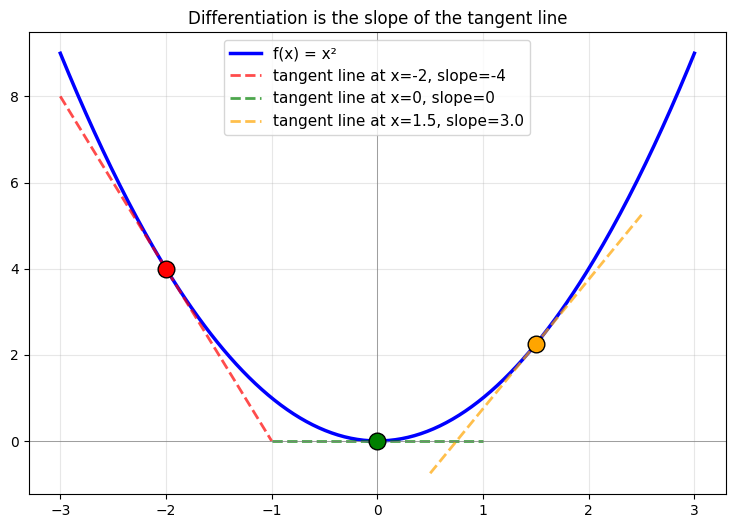

In [3]:
f = lambda x: x**2
df = lambda x: 2*x

fig, ax = plt.subplots(figsize=(9, 6))

# 함수 그래프
xs = np.linspace(-3, 3, 300)
ax.plot(xs, f(xs), 'b-', linewidth=2.5, label='f(x) = x²')

# 여러 점에서 접선
for a, color in [(-2, 'red'), (0, 'green'), (1.5, 'orange')]:
    slope = df(a)
    fa = f(a)
    xs_tan = np.linspace(a-1, a+1, 30)
    tangent = slope*(xs_tan - a) + fa
    ax.plot(xs_tan, tangent, '--', color=color, linewidth=2, alpha=0.7,
            label=f"tangent line at x={a}, slope={slope}")
    ax.plot(a, fa, 'o', color=color, markersize=12, markeredgecolor='black', zorder=5)

ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.legend(fontsize=11); ax.grid(alpha=0.3)
ax.set_title('Differentiation is the slope of the tangent line')
plt.show()

---
## 예제 3: 편미분 시각화 (3D surface + 1D slice)

**수업 슬라이드 9-10과 대응**

$f(x, y) = x^2 + 3xy + y^2$의 편미분을 그림으로 확인합니다.

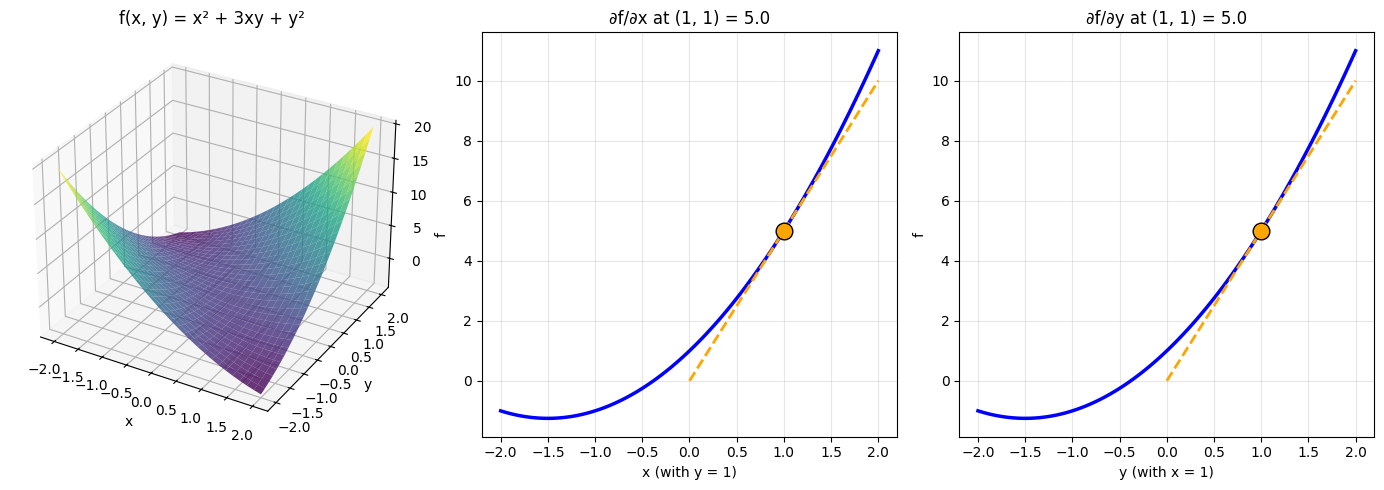


Partial derivative at the point (1, 1):
  ∂f/∂x = 2(1) + 3(1) = 5.0
  ∂f/∂y = 3(1) + 2(1) = 5.0


In [4]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

f = lambda x, y: x**2 + 3*x*y + y**2

# 편미분 (analytical)
df_dx = lambda x, y: 2*x + 3*y   # ∂f/∂x
df_dy = lambda x, y: 3*x + 2*y   # ∂f/∂y

# 평가 지점
a, b = 1.0, 1.0
fab = f(a, b)              # = 5
slope_x = df_dx(a, b)      # = 5
slope_y = df_dy(a, b)      # = 5

fig = plt.figure(figsize=(14, 5))

# ---------- 1. 3D Surface ----------
ax1 = fig.add_subplot(131, projection='3d')
xs = np.linspace(-2, 2, 30); ys = np.linspace(-2, 2, 30)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.set_title('f(x, y) = x² + 3xy + y²')
ax1.set_xlabel('x'); ax1.set_ylabel('y')

# ---------- 2. y=1 고정, x 방향 slice ----------
ax2 = fig.add_subplot(132)
xs_slice = np.linspace(-2, 2, 100)
ax2.plot(xs_slice, f(xs_slice, b), 'b-', linewidth=2.5)

# ⭐ 추가: 접점
ax2.plot(a, fab, 'o', color='orange', markersize=12,
         markeredgecolor='black', zorder=5)

# ⭐ 추가: 접선 (점 (a, fab)를 지나고 기울기 slope_x)
xs_tan = np.linspace(a - 1, a + 1, 30)
tangent_x = slope_x * (xs_tan - a) + fab
ax2.plot(xs_tan, tangent_x, '--', color='orange', linewidth=2)

ax2.set_xlabel('x (with y = 1)'); ax2.set_ylabel('f')
ax2.set_title(f'∂f/∂x at (1, 1) = {slope_x}')
ax2.grid(alpha=0.3)

# ---------- 3. x=1 고정, y 방향 slice ----------
ax3 = fig.add_subplot(133)
ys_slice = np.linspace(-2, 2, 100)
ax3.plot(ys_slice, f(a, ys_slice), 'b-', linewidth=2.5)

# ⭐ 추가: 접점
ax3.plot(b, fab, 'o', color='orange', markersize=12,
         markeredgecolor='black', zorder=5)

# ⭐ 추가: 접선
ys_tan = np.linspace(b - 1, b + 1, 30)
tangent_y = slope_y * (ys_tan - b) + fab
ax3.plot(ys_tan, tangent_y, '--', color='orange', linewidth=2)

ax3.set_xlabel('y (with x = 1)'); ax3.set_ylabel('f')
ax3.set_title(f'∂f/∂y at (1, 1) = {slope_y}')
ax3.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("\nPartial derivative at the point (1, 1):")
print(f"  ∂f/∂x = 2(1) + 3(1) = {slope_x}")
print(f"  ∂f/∂y = 3(1) + 2(1) = {slope_y}")

---
## 예제 4: 그래디언트 벡터장

**수업 슬라이드 11-12와 대응**

등고선과 그래디언트 화살표를 동시에 그립니다. 그래디언트는 등고선에 수직이며 가장 가파른 상승 방향을 가리킵니다.

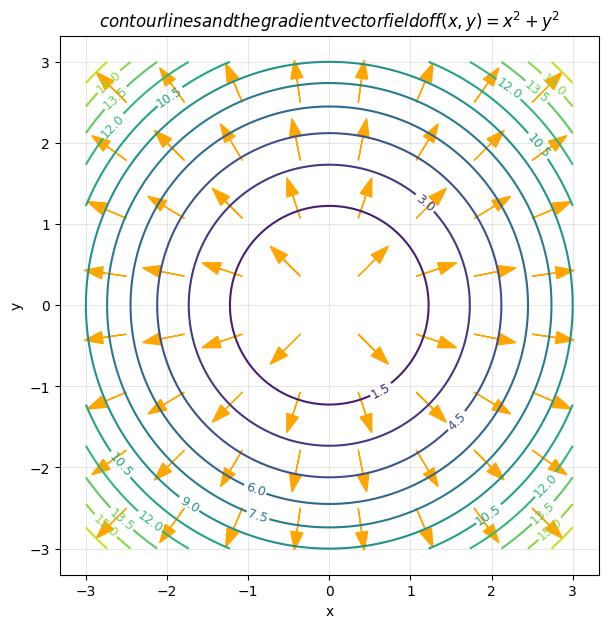

In [5]:
f = lambda x, y: x**2 + y**2
grad_f = lambda x, y: np.array([2*x, 2*y])  # 해석적 그래디언트

fig, ax = plt.subplots(figsize=(8, 7))

# 등고선
xs = np.linspace(-3, 3, 100); ys = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(xs, ys)
Z = f(X, Y)
contour = ax.contour(X, Y, Z, levels=12, cmap='viridis')
ax.clabel(contour, inline=True, fontsize=9)

# 그래디언트 화살표
xs_arr = np.linspace(-2.5, 2.5, 8)
ys_arr = np.linspace(-2.5, 2.5, 8)
for x in xs_arr:
    for y in ys_arr:
        if abs(x) < 0.1 and abs(y) < 0.1:
            continue
        g = grad_f(x, y)
        norm = np.linalg.norm(g)
        if norm > 0:
            g = g / norm * 0.3  # 단위 벡터 × 표시 크기
            ax.arrow(x, y, g[0], g[1], head_width=0.15, fc='orange', ec='orange')

ax.set_title('$contour lines and the gradient vector field of f(x,y) = x^2+y^2$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.grid(alpha=0.3); ax.set_aspect('equal')
plt.show()

**관찰**: 
- 모든 화살표가 원점에서 바깥쪽으로 향함 (원형 bowl이므로)
- 화살표는 항상 등고선에 수직
- 원점에서 멀어질수록 화살표가 길어짐 (그래디언트 크기가 커짐)

---
## 예제 5: Sigmoid 미분 확인

**수업 슬라이드 22-24와 대응**

유도한 $\sigma'(x) = \sigma(x)(1-\sigma(x))$가 실제로 맞는지 수치 미분과 비교합니다.

In [6]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_derivative_analytical(x):
    """유도한 공식: σ'(x) = σ(x)(1-σ(x))"""
    s = sigmoid(x)
    return s * (1 - s)

# 수치 미분과 비교
xs = np.linspace(-5, 5, 11)
print("x     | 수치 미분    | 해석 미분    | 차이")
print("-" * 55)
for x in xs:
    num = numerical_derivative(sigmoid, x)
    ana = sigmoid_derivative_analytical(x)
    print(f"{x:+.1f}  | {num:.8f}  | {ana:.8f}  | {abs(num-ana):.2e}")

x     | 수치 미분    | 해석 미분    | 차이
-------------------------------------------------------
-5.0  | 0.00664806  | 0.00664806  | 1.29e-13
-4.0  | 0.01766271  | 0.01766271  | 4.88e-14
-3.0  | 0.04517666  | 0.04517666  | 6.29e-13
-2.0  | 0.10499359  | 0.10499359  | 8.00e-13
-1.0  | 0.19661193  | 0.19661193  | 1.01e-12
+0.0  | 0.25000000  | 0.25000000  | 6.69e-12
+1.0  | 0.19661193  | 0.19661193  | 1.76e-12
+2.0  | 0.10499359  | 0.10499359  | 5.66e-12
+3.0  | 0.04517666  | 0.04517666  | 1.11e-12
+4.0  | 0.01766271  | 0.01766271  | 6.54e-12
+5.0  | 0.00664806  | 0.00664806  | 1.04e-12


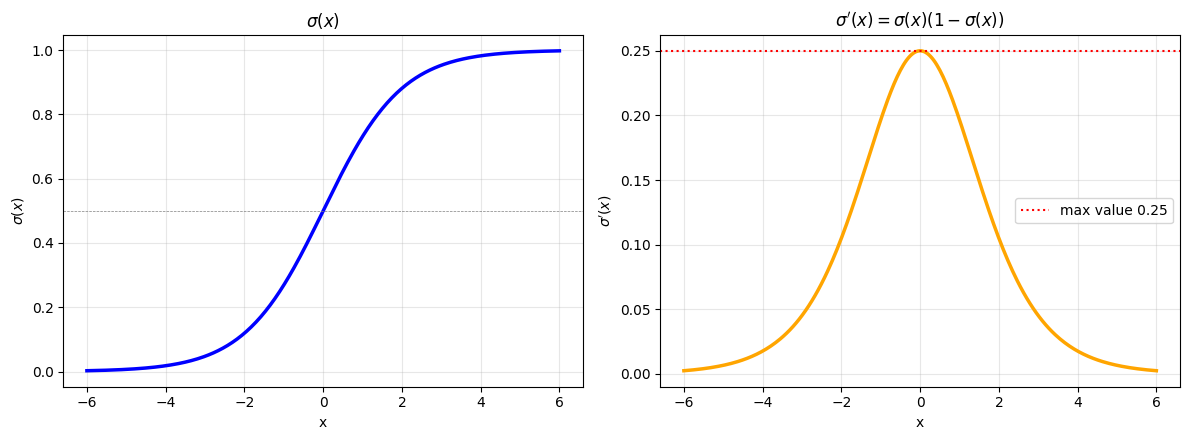


중요: σ'의 최댓값은 0.2500 (x=0에서)
→ 층이 깊어질수록 곱해지는 요소가 0.25 이하 → vanishing gradient


In [7]:
# 시각화: sigmoid와 그 미분
xs = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(xs, sigmoid(xs), 'b-', linewidth=2.5)
axes[0].set_title(r'$\sigma(x)$')
axes[0].axhline(0.5, color='gray', lw=0.5, linestyle='--')
axes[0].grid(alpha=0.3)
axes[0].set_xlabel('x'); axes[0].set_ylabel(r'$\sigma(x)$')

axes[1].plot(xs, sigmoid_derivative_analytical(xs), 'orange', linewidth=2.5)
axes[1].set_title(r"$\sigma'(x) = \sigma(x)(1-\sigma(x))$")
axes[1].axhline(0.25, color='red', lw=1.5, linestyle=':', label='max value 0.25')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlabel('x'); axes[1].set_ylabel(r"$\sigma'(x)$")

plt.tight_layout(); plt.show()

print(f"\n중요: σ'의 최댓값은 {sigmoid_derivative_analytical(0):.4f} (x=0에서)")
print("→ 층이 깊어질수록 곱해지는 요소가 0.25 이하 → vanishing gradient")

---
## 예제 6: Gradient Descent 1D 실습

**수업 슬라이드 25-27과 대응**

제공된 `gradient_descent.py`를 사용해서 learning rate의 영향을 관찰합니다.

  lr=0.01: 시작 x=5, 최종 x=2.7274
  lr=0.1: 시작 x=5, 최종 x=0.0062
  lr=0.5: 시작 x=5, 최종 x=0.0000
  lr=1.01: 시작 x=5, 최종 x=9.0568


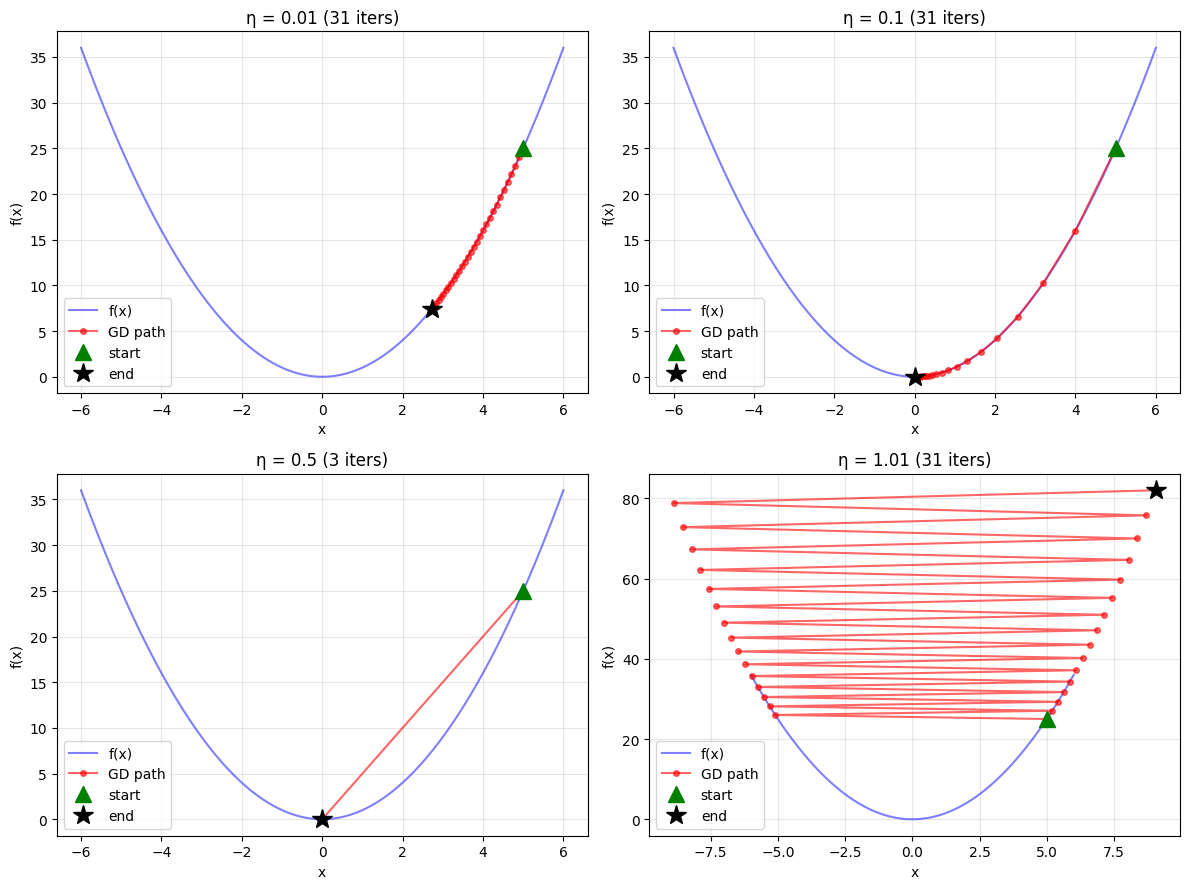

In [8]:
from gradient_descent import gradient_descent_1d, plot_trajectory_1d

# f(x) = x^2 에서 여러 learning rate 실험
f = lambda x: x**2
df = lambda x: 2*x

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, lr in zip(axes, [0.01, 0.1, 0.5, 1.01]):
    traj = gradient_descent_1d(f, df, x0=5.0, lr=lr, n_iters=30)
    plot_trajectory_1d(f, traj, x_range=(-6, 6), title=f'η = {lr}', ax=ax)
    print(f"  lr={lr}: 시작 x=5, 최종 x={traj[-1][0]:.4f}")

plt.tight_layout(); plt.show()

**관찰**:
- lr=0.01: 너무 느림, 30번 반복에도 목표 x=0에 도달 못함
- lr=0.1: 적절, 빠르게 수렴
- lr=0.5: 공격적이지만 수렴
- lr=1.01: 발산! 매 단계마다 멀어짐

---
## 예제 7: Non-convex 함수에서 초기값의 영향

**수업 슬라이드 28과 대응**

$f(x) = x^2 \sin(x)$는 여러 local minima를 가집니다. 초기값에 따라 다른 답에 수렴합니다.

  x₀=-4.0: 최종 x=-2.289, f(x)=-3.945
  x₀=0.5: 최종 x=0.126, f(x)=0.002
  x₀=4.0: 최종 x=5.087, f(x)=-24.083


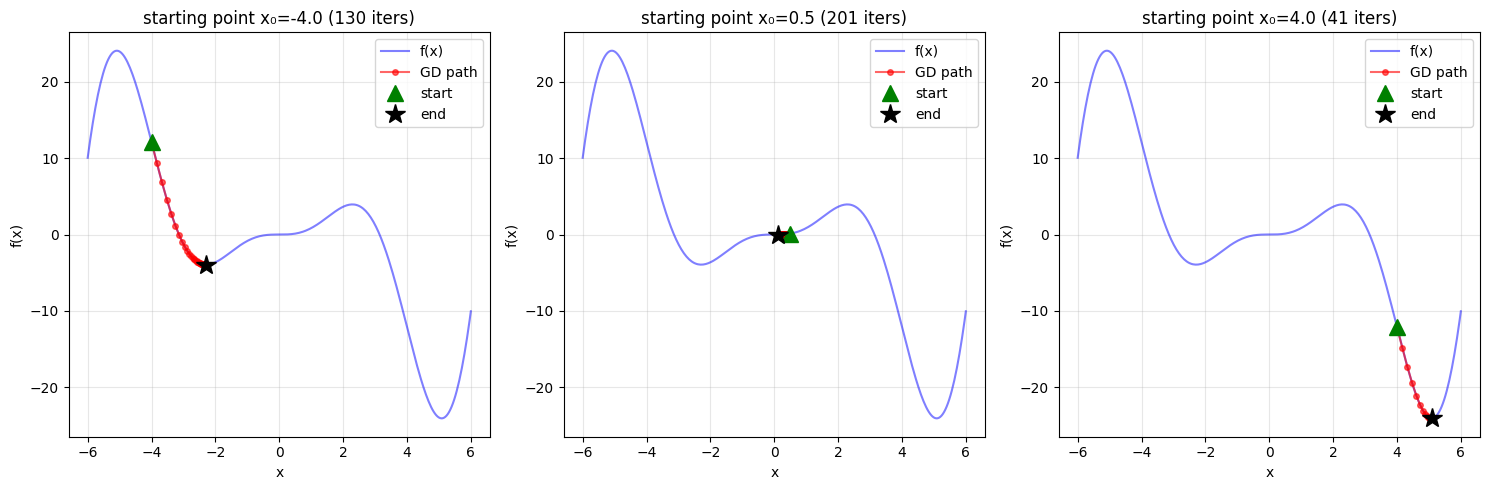

In [11]:
f = lambda x: x**2 * np.sin(x)
df = lambda x: 2*x*np.sin(x) + x**2*np.cos(x)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, x0 in zip(axes, [-4.0, 0.5, 4.0]):
    traj = gradient_descent_1d(f, df, x0=x0, lr=0.01, n_iters=200)
    plot_trajectory_1d(f, traj, x_range=(-6, 6), title=f'starting point x₀={x0}', ax=ax)
    final = traj[-1]
    print(f"  x₀={x0}: 최종 x={final[0]:.3f}, f(x)={f(final[0]):.3f}")

plt.tight_layout(); plt.show()

**관찰**: 세 초기값이 서로 다른 local minimum에 수렴합니다. 신경망에서는 **초기화(initialization)**가 매우 중요한 이유입니다.

---
## 예제 8: 2D Gradient Descent

**수업 슬라이드 29와 대응**

타원형 함수에서는 진동이 발생합니다.

C:\Users\yongo\AppData\Local\Temp\ipykernel_30084\3309074529.py:19: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yongo\AppData\Local\Temp\ipykernel_30084\3309074529.py:19: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


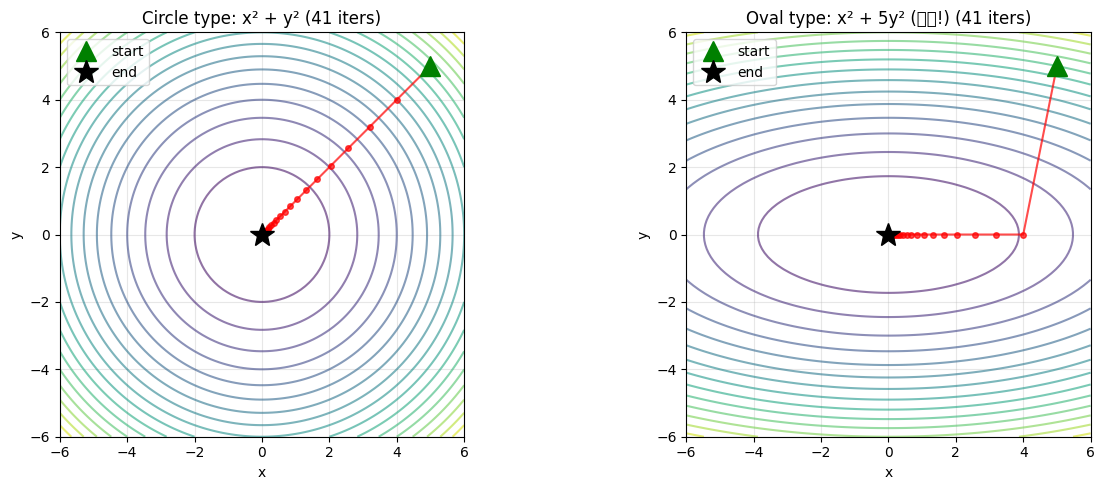

In [12]:
from gradient_descent import gradient_descent_2d, plot_contour_trajectory

f1 = lambda x, y: x**2 + y**2      # 원형 (대칭)
grad_f1 = lambda x, y: np.array([2*x, 2*y])

f2 = lambda x, y: x**2 + 5*y**2     # 타원 (비대칭)
grad_f2 = lambda x, y: np.array([2*x, 10*y])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

traj1 = gradient_descent_2d(f1, grad_f1, x0=[5.0, 5.0], lr=0.1, n_iters=40)
plot_contour_trajectory(f1, traj1, x_range=(-6, 6), y_range=(-6, 6),
                        title='Circle type: x² + y²', ax=axes[0])

traj2 = gradient_descent_2d(f2, grad_f2, x0=[5.0, 5.0], lr=0.1, n_iters=40)
plot_contour_trajectory(f2, traj2, x_range=(-6, 6), y_range=(-6, 6),
                        title='Oval type: x² + 5y² (진동!)', ax=axes[1])

plt.tight_layout(); plt.show()

**관찰**: 타원형에서는 y 방향(곡률이 큰 쪽)에서 진동하며 x 방향으로 천천히 이동합니다. 이 문제가 **Momentum, Adam 등 고급 optimizer가 발전한 이유**입니다.